In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Module Loaded")

Module Loaded


In [2]:
# Our squad's batting data: 5 players x 14 matches (same shape as last session)

PLAYERS = ["Virat", "Rohit", "Hardik", "Shubman", "Shreyas"]

squad_scores = np.array([
    [72, 45, 88, 31, 64,  0, 103, 52, 19, 77, 41, 93, 28, 66],   # Virat
    [56,  0, 74, 88, 32, 45,  61, 17, 90, 38, 72,  5, 83, 49],   # Rohit
    [45, 32,  0, 67, 18, 54,  78, 22, 41, 33, 60, 15, 88, 27],   # Hardik
    [33, 61, 45,  0, 77, 83,  22, 58, 44, 71,  0, 66, 31, 52],   # Shubman
    [88, 14, 57, 72,  0, 38,  91, 43, 66, 22, 84,  0, 47, 73],   # Shreyas
])

# Balls faced per player per match (needed later for strike rate)
balls_faced = np.array([
    [48, 32, 55, 24, 41,  0, 61, 38, 16, 50, 29, 58, 22, 44],
    [39,  0, 50, 56, 25, 33,  42, 14, 58, 27, 49,  6, 54, 35],
    [31, 24,  0, 46, 15, 38,  51, 18, 30, 26, 42, 12, 56, 21],
    [25, 42, 33,  0, 52, 56,  18, 40, 32, 47,  0, 44, 24, 36],
    [56, 12, 39, 48,  0, 28,  60, 31, 44, 17, 53,  0, 34, 47],
])

print(f"squad_scores shape: {squad_scores.shape}")
print(f"balls_faced shape:  {balls_faced.shape}")
print()
print("Both arrays have the same shape — this matters for what comes next.")

squad_scores shape: (5, 14)
balls_faced shape:  (5, 14)

Both arrays have the same shape — this matters for what comes next.


In [3]:
squad_scores.shape

(5, 14)

In [4]:
balls_faced.shape

(5, 14)


#  Element-wise Operations, Properly

## The rule

An element-wise operation takes two arrays of the **same shape** and combines them position by position. Position `[i, j]` in the result comes only from position `[i, j]` in each input.

```
squad_scores[1, 4]   <-- Rohit's runs in match 5
balls_faced[1, 4]    <-- Rohit's balls faced in match 5

strike_rate[1, 4] = squad_scores[1, 4] / balls_faced[1, 4] * 100
```

This relationship holds for **every single position** in the array, computed all at once.

In [6]:
import warnings
warnings.filterwarnings('ignore')
(squad_scores / balls_faced) * 100

array([[150.        , 140.625     , 160.        , 129.16666667,
        156.09756098,          nan, 168.85245902, 136.84210526,
        118.75      , 154.        , 141.37931034, 160.34482759,
        127.27272727, 150.        ],
       [143.58974359,          nan, 148.        , 157.14285714,
        128.        , 136.36363636, 145.23809524, 121.42857143,
        155.17241379, 140.74074074, 146.93877551,  83.33333333,
        153.7037037 , 140.        ],
       [145.16129032, 133.33333333,          nan, 145.65217391,
        120.        , 142.10526316, 152.94117647, 122.22222222,
        136.66666667, 126.92307692, 142.85714286, 125.        ,
        157.14285714, 128.57142857],
       [132.        , 145.23809524, 136.36363636,          nan,
        148.07692308, 148.21428571, 122.22222222, 145.        ,
        137.5       , 151.06382979,          nan, 150.        ,
        129.16666667, 144.44444444],
       [157.14285714, 116.66666667, 146.15384615, 150.        ,
                 nan

In [7]:
squad_scores

array([[ 72,  45,  88,  31,  64,   0, 103,  52,  19,  77,  41,  93,  28,
         66],
       [ 56,   0,  74,  88,  32,  45,  61,  17,  90,  38,  72,   5,  83,
         49],
       [ 45,  32,   0,  67,  18,  54,  78,  22,  41,  33,  60,  15,  88,
         27],
       [ 33,  61,  45,   0,  77,  83,  22,  58,  44,  71,   0,  66,  31,
         52],
       [ 88,  14,  57,  72,   0,  38,  91,  43,  66,  22,  84,   0,  47,
         73]])

In [8]:
balls_faced

array([[48, 32, 55, 24, 41,  0, 61, 38, 16, 50, 29, 58, 22, 44],
       [39,  0, 50, 56, 25, 33, 42, 14, 58, 27, 49,  6, 54, 35],
       [31, 24,  0, 46, 15, 38, 51, 18, 30, 26, 42, 12, 56, 21],
       [25, 42, 33,  0, 52, 56, 18, 40, 32, 47,  0, 44, 24, 36],
       [56, 12, 39, 48,  0, 28, 60, 31, 44, 17, 53,  0, 34, 47]])

In [9]:
squad_scores.shape

(5, 14)

In [10]:
balls_faced.shape

(5, 14)

In [11]:
strike_rate = (squad_scores / balls_faced) * 100

print("Strike rate (runs per 100 balls):")
print(strike_rate.round(1))
print()
print("Notice the 'nan' values — those are 0/0 (did not bat that match).")
print("NumPy does not crash on division by zero — it returns nan or inf and warns you.")

Strike rate (runs per 100 balls):
[[150.  140.6 160.  129.2 156.1   nan 168.9 136.8 118.8 154.  141.4 160.3
  127.3 150. ]
 [143.6   nan 148.  157.1 128.  136.4 145.2 121.4 155.2 140.7 146.9  83.3
  153.7 140. ]
 [145.2 133.3   nan 145.7 120.  142.1 152.9 122.2 136.7 126.9 142.9 125.
  157.1 128.6]
 [132.  145.2 136.4   nan 148.1 148.2 122.2 145.  137.5 151.1   nan 150.
  129.2 144.4]
 [157.1 116.7 146.2 150.    nan 135.7 151.7 138.7 150.  129.4 158.5   nan
  138.2 155.3]]

Notice the 'nan' values — those are 0/0 (did not bat that match).
NumPy does not crash on division by zero — it returns nan or inf and warns you.


In [12]:
a = np.array([1, 2, 3])
b = np.array([4, 6, 7])

In [13]:
a

array([1, 2, 3])

In [14]:
b

array([4, 6, 7])

In [15]:
np.where((a + b) % 2 == 0, a, b)

array([4, 2, 3])

In [16]:
a


array([1, 2, 3])

In [17]:
np.maximum(a,b,a)

array([4, 6, 7])

In [18]:
a = np.array([4, 6, 7])
b = np.array([1, 5, 3])

np.maximum(a, b)

array([4, 6, 7])

In [19]:
a

array([4, 6, 7])

In [20]:
b

array([1, 5, 3])

In [21]:
# A cleaner way: use np.where() to handle the zero-balls case explicitly
# np.where(condition, value_if_true, value_if_false) — itself fully vectorized

strike_rate_clean = np.where(
    balls_faced > 0,                       # condition, checked element-wise
    (squad_scores / np.maximum(balls_faced, 1)) * 100,   # avoid division by zero
    0                                       # value to use where condition is False
)

print("Strike rate (cleaned, 0 where player did not bat):")
print(strike_rate_clean.round(1))
print()
print("np.where() is itself a vectorized operation — no loop, even though")
print("it behaves like an if/else applied to every element.")

Strike rate (cleaned, 0 where player did not bat):
[[150.  140.6 160.  129.2 156.1   0.  168.9 136.8 118.8 154.  141.4 160.3
  127.3 150. ]
 [143.6   0.  148.  157.1 128.  136.4 145.2 121.4 155.2 140.7 146.9  83.3
  153.7 140. ]
 [145.2 133.3   0.  145.7 120.  142.1 152.9 122.2 136.7 126.9 142.9 125.
  157.1 128.6]
 [132.  145.2 136.4   0.  148.1 148.2 122.2 145.  137.5 151.1   0.  150.
  129.2 144.4]
 [157.1 116.7 146.2 150.    0.  135.7 151.7 138.7 150.  129.4 158.5   0.
  138.2 155.3]]

np.where() is itself a vectorized operation — no loop, even though
it behaves like an if/else applied to every element.


In [22]:
# Element-wise comparison between two players
# Who scored more, Virat or Rohit, in each match?

virat = squad_scores[0]   # row 0
rohit = squad_scores[1]   # row 1

virat_scored_more = virat > rohit

print("Match-by-match comparison (Virat vs Rohit):")
for i in range(14):
    winner = "Virat" if virat_scored_more[i] else ("Rohit" if rohit[i] > virat[i] else "Tied")
    print(f"  Match {i+1:>2}: Virat={virat[i]:>3}  Rohit={rohit[i]:>3}  -> {winner}")

print()
print(f"Virat outscored Rohit in {virat_scored_more.sum()} of 14 matches")

Match-by-match comparison (Virat vs Rohit):
  Match  1: Virat= 72  Rohit= 56  -> Virat
  Match  2: Virat= 45  Rohit=  0  -> Virat
  Match  3: Virat= 88  Rohit= 74  -> Virat
  Match  4: Virat= 31  Rohit= 88  -> Rohit
  Match  5: Virat= 64  Rohit= 32  -> Virat
  Match  6: Virat=  0  Rohit= 45  -> Rohit
  Match  7: Virat=103  Rohit= 61  -> Virat
  Match  8: Virat= 52  Rohit= 17  -> Virat
  Match  9: Virat= 19  Rohit= 90  -> Rohit
  Match 10: Virat= 77  Rohit= 38  -> Virat
  Match 11: Virat= 41  Rohit= 72  -> Rohit
  Match 12: Virat= 93  Rohit=  5  -> Virat
  Match 13: Virat= 28  Rohit= 83  -> Rohit
  Match 14: Virat= 66  Rohit= 49  -> Virat

Virat outscored Rohit in 9 of 14 matches



### Exercise 1 — Element-wise Operations

**Task:** Complete the calculations below. Each should be a single vectorized expression — no loops.

# 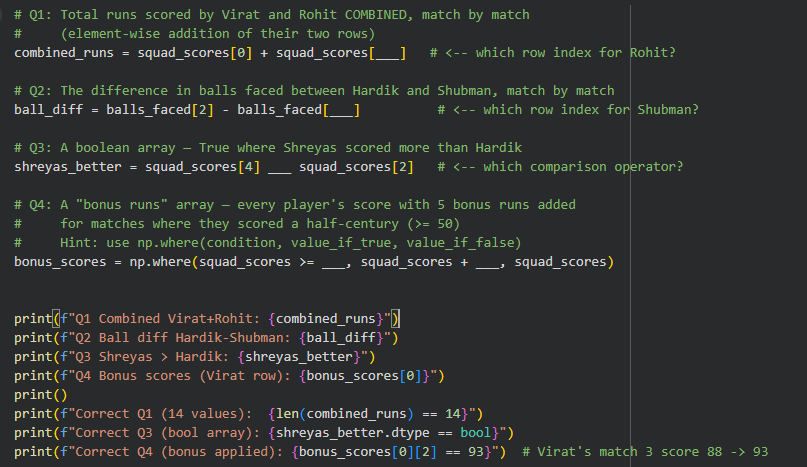

In [24]:
combined_runs   = squad_scores[0] + squad_scores[1]
ball_diff       = balls_faced[2] - balls_faced[3]
shreyas_better  = squad_scores[4] > squad_scores[2]
bonus_scores    = np.where(squad_scores >= 50, squad_scores + 5, squad_scores)

In [25]:
combined_runs

array([128,  45, 162, 119,  96,  45, 164,  69, 109, 115, 113,  98, 111,
       115])

In [26]:
ball_diff

array([  6, -18, -33,  46, -37, -18,  33, -22,  -2, -21,  42, -32,  32,
       -15])

In [27]:
shreyas_better

array([ True, False,  True,  True, False, False,  True,  True,  True,
       False,  True, False, False,  True])

In [28]:
bonus_scores

array([[ 77,  45,  93,  31,  69,   0, 108,  57,  19,  82,  41,  98,  28,
         71],
       [ 61,   0,  79,  93,  32,  45,  66,  17,  95,  38,  77,   5,  88,
         49],
       [ 45,  32,   0,  72,  18,  59,  83,  22,  41,  33,  65,  15,  93,
         27],
       [ 33,  66,  45,   0,  82,  88,  22,  63,  44,  76,   0,  71,  31,
         57],
       [ 93,  14,  62,  77,   0,  38,  96,  43,  71,  22,  89,   0,  47,
         78]])

#  Broadcasting

## The problem broadcasting solves

Element-wise operations require both arrays to have the **same shape**. But very often, you want to combine a big array with a smaller one — for example:

- Add a fixed bonus of 10 runs to every score in the entire `(5, 14)` squad array
- Apply a different adjustment to each player (5 values) across all 14 matches
- Apply a different adjustment to each match (14 values) across all 5 players

None of these involve two arrays of the same shape. **Broadcasting** is the set of rules NumPy uses to "stretch" smaller arrays so they fit a larger one, without actually copying any data in memory.

---

## Broadcasting rule 1: scalar with array

You already used this in Session 5.1 without naming it:

```python
squad_scores + 10
```

The scalar `10` is broadcast to match every position in the `(5, 14)` array. This is the simplest case of broadcasting.

In [29]:
runs = np.array([50, 80, 30, 100])

result = runs + 10

In [30]:
result

array([ 60,  90,  40, 110])

In [31]:
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

In [32]:
a+b

array([11, 22, 33])

In [33]:
scores = np.array([
    [50, 80, 30],
    [40, 70, 20]
])

bonus = np.array([10, 10, 10])

In [34]:
scores

array([[50, 80, 30],
       [40, 70, 20]])

In [35]:
bonus

array([10, 10, 10])

In [36]:
scores + bonus

array([[60, 90, 40],
       [50, 80, 30]])

| Shape A   | Shape B       | Possible? | Result Shape | Reason                             |
| --------- | ------------- | --------- | ------------ | ---------------------------------- |
| `(3,)`    | `(3,)`        | ✅ Yes     | `(3,)`       | Same shape                         |
| `(3,)`    | `(1,)`        | ✅ Yes     | `(3,)`       | 1 expands to 3                     |
| `(2,3)`   | `(3,)`        | ✅ Yes     | `(2,3)`      | Last dimension matches             |
| `(2,3)`   | `(1,3)`       | ✅ Yes     | `(2,3)`      | First dimension expands            |
| `(2,3)`   | `(2,1)`       | ✅ Yes     | `(2,3)`      | Second dimension expands           |
| `(3,1)`   | `(1,3)`       | ✅ Yes     | `(3,3)`      | Both dimensions expand             |
| `(4,1)`   | `(4,)`        | ✅ Yes     | `(4,4)`      | `(4,) → (1,4)`                     |
| `(2,1,3)` | `(1,4,3)`     | ✅ Yes     | `(2,4,3)`    | Middle and first dimensions expand |
| `(2,3)`   | `(2,2)`       | ❌ No      | Error        | 3 ≠ 2                              |
| `(3,)`    | `(4,)`        | ❌ No      | Error        | Different sizes                    |
| `(2,3)`   | `(4,)`        | ❌ No      | Error        | Last dimension mismatch            |
| `(2,3,4)` | `(3,4)`       | ✅ Yes     | `(2,3,4)`    | Missing dimension treated as 1     |
| `(5,2,3)` | `(2,3)`       | ✅ Yes     | `(5,2,3)`    | Leading dimension expands          |
| `(2,3)`   | `()` (scalar) | ✅ Yes     | `(2,3)`      | Scalar broadcasts everywhere       |


In [37]:
# Scalar broadcasting — the simplest case

print("Original shape:", squad_scores.shape)
print()

bonus_flat = squad_scores + 10
print("squad_scores + 10  (every value gets +10):")
print(bonus_flat)
print()
print("The scalar 10 was 'broadcast' to all 70 positions (5 x 14) automatically.")

Original shape: (5, 14)

squad_scores + 10  (every value gets +10):
[[ 82  55  98  41  74  10 113  62  29  87  51 103  38  76]
 [ 66  10  84  98  42  55  71  27 100  48  82  15  93  59]
 [ 55  42  10  77  28  64  88  32  51  43  70  25  98  37]
 [ 43  71  55  10  87  93  32  68  54  81  10  76  41  62]
 [ 98  24  67  82  10  48 101  53  76  32  94  10  57  83]]

The scalar 10 was 'broadcast' to all 70 positions (5 x 14) automatically.
